In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import copy

from scipy.sparse import coo_matrix, block_diag, identity, hstack, csr_matrix, csc_matrix, vstack
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time 
import matplotlib as mpl

from pyiga import assemble, bspline, vform, geometry, vis, solvers, utils, topology, ieti, algebra, operators, adaptive
from pyiga import algebra_cy, ieti_cy, bspline_cy

from scipy.sparse.linalg import aslinearoperator as LinOp

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

In [2]:
def draw_loglog_slope(fig, ax, origin, width_inches, slope, inverted=False, color=None, polygon_kwargs=None, label=True, labelcolor=None, label_kwargs=None, zorder=None):
    """
    This function draws slopes or "convergence triangles" into loglog plots.
    @param fig: The figure
    @param ax: The axes object to draw to
    @param origin: The 2D origin (usually lower-left corner) coordinate of the triangle
    @param width_inches: The width in inches of the triangle
    @param slope: The slope of the triangle, i.e. order of convergence
    @param inverted: Whether to mirror the triangle around the origin, i.e. whether 
        it indicates the slope towards the lower left instead of upper right (defaults to false)
    @param color: The color of the of the triangle edges (defaults to default color)
    @param polygon_kwargs: Additional kwargs to the Polygon draw call that creates the slope
    @param label: Whether to enable labeling the slope (defaults to true)
    @param labelcolor: The color of the slope labels (defaults to the edge color)
    @param label_kwargs: Additional kwargs to the Annotation draw call that creates the labels
    @param zorder: The z-order value of the triangle and labels, defaults to a high value
    """

    if polygon_kwargs is None:
        polygon_kwargs = {}
    if label_kwargs is None:
        label_kwargs = {}

    if color is not None:
        polygon_kwargs["color"] = color
    if "linewidth" not in polygon_kwargs:
        polygon_kwargs["linewidth"] = 0.75 * mpl.rcParams["lines.linewidth"]
    if labelcolor is not None:
        label_kwargs["color"] = labelcolor
    if "color" not in label_kwargs:
        label_kwargs["color"] = polygon_kwargs["color"]
    if "fontsize" not in label_kwargs:
        label_kwargs["fontsize"] = 0.75 * mpl.rcParams["font.size"]

    if inverted:
        width_inches = -width_inches
    if zorder is None:
        zorder = 10

    # For more information on coordinate transformations in Matplotlib see
    # https://matplotlib.org/3.1.1/tutorials/advanced/transforms_tutorial.html

    # Convert the origin into figure coordinates in inches
    origin_disp = ax.transData.transform(origin)
    origin_dpi = fig.dpi_scale_trans.inverted().transform(origin_disp)

    # Obtain the top-right corner in data coordinates
    corner_dpi = origin_dpi + width_inches * np.array([1.0, 0.0])
    corner_disp = fig.dpi_scale_trans.transform(corner_dpi)
    corner = ax.transData.inverted().transform(corner_disp)

    (x1, y1) = (origin[0], origin[1])
    x2 = corner[0]

    # The width of the triangle in data coordinates
    width = x2 - x1
    # Compute offset of the slope
    log_offset = y1 / (x1 ** (-slope))

    y2 = log_offset * (x2 ** (-slope))
    height = y2 - y1

    # The vertices of the slope
    a = origin
    b = corner
    c = [x2, y2]

    # Draw the slope triangle
    X = np.array([a, b, c])
    triangle = plt.Polygon(X[:3,:], fill=False, zorder=zorder, **polygon_kwargs)
    ax.add_patch(triangle)

    # Convert vertices into display space
    a_disp = ax.transData.transform(a)
    b_disp = ax.transData.transform(b)
    c_disp = ax.transData.transform(c)

    # Figure out the center of the triangle sides in display space
    bottom_center_disp = a_disp + 0.5 * (b_disp - a_disp)
    bottom_center = ax.transData.inverted().transform(bottom_center_disp)

    right_center_disp = b_disp + 0.5 * (c_disp - b_disp)
    right_center = ax.transData.inverted().transform(right_center_disp)

    # Label alignment depending on inversion parameter
    va_xlabel = "bottom" if not inverted else "top"
    ha_ylabel = "left" if not inverted else "right"

    # Label offset depending on inversion parameter
    offset_xlabel = [0.0, 0.33 * label_kwargs["fontsize"]] if not inverted else [0.0, -0.33 * label_kwargs["fontsize"]]
    offset_ylabel = [0.33 * label_kwargs["fontsize"], 0.0] if not inverted else [-0.33 * label_kwargs["fontsize"], 0.0]

    # Draw the slope labels
    ax.annotate("$1$", bottom_center, xytext=offset_xlabel, textcoords='offset points', ha="center", va=va_xlabel, zorder=zorder, **label_kwargs)
    ax.annotate(f"${slope}$", right_center, xytext=offset_ylabel, textcoords='offset points', ha=ha_ylabel, va="center", zorder=zorder, **label_kwargs)


In [3]:
def Lshape(deg, N, k=1):
    kvs = [2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),),2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),)]

    # define geometry
    geos = [
        geometry.Quad(np.array([[-1,-1],[0,-1],[-1,1],[0,0]]).T),
        geometry.Quad(np.array([[-1,1],[0,0],[1,1],[1,0]]).T)
    ]

    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    return M

In [4]:
def LshapeAnullus(deg, N, k=1):
    kvs = 3*[2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),)]

    # define geometry
    geos = [
        geometry.annulus(r1=1.5, r2=2, phi = np.pi/4),
        geometry.annulus(r1=1.5, r2=2, phi = np.pi/4).rotate_2d(angle=np.pi/4),
        geometry.annulus(r1=1.0, r2=1.5, phi = np.pi/4).rotate_2d(angle=np.pi/4),
    ]

    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    M.outer_boundaries[0].add((1,(0,0)))
    return M

In [5]:
def cart2pol(x, y):
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return(r, phi%(2*np.pi))
def u(x,y):
    r, phi = cart2pol(x,y)
    return r**(2/3)*np.sin(2*phi/3)
def ux(x,y):
    r, phi = cart2pol(x,y)
    return -2./3*r**(-1./3)*np.sin(phi/3)
def uy(x,y):
    r, phi = cart2pol(x,y)
    return 2./3*r**(-1./3)*np.cos(phi/3)

In [6]:
f = 0
dir_data= {0:u}

In [21]:
degs = (2,3,5,8)
maxpatches =(4000,3000,2000,2000)
#maxiter=(7,7,7,6)
maxiter=4*(5,5,5,50)
eps=(1e-7,1e-8,1e-8,2*1e-8)
plot=1

R = np.zeros((max(maxiter),len(degs)*5))

for i,deg in enumerate(degs):
    print("#########################################")
    N = deg+1
    M = Lshape(deg,N,1)

    MB = assemble.MultiBasis(M, subspace='C0')
    eta=1.0
    k=0
    while k<maxiter[i]:
        if plot:
            M.plotmesh(figsize=(10,10), knots=1, nodes=50, bwidth=0.01, patch_idx=0)
            plt.axis('off');
            plt.axis('scaled');
            #plt.savefig('/home/wolfman/Pictures/p'+str(deg)+'i'+str(k)+'.png',dpi=100,bbox_inches='tight');
            plt.savefig('/mnt/c/Users/stefa/Pictures/p'+str(deg)+'i'+str(k)+'.png', bbox_inches='tight',dpi=100)
            #plt.show();
            plt.close();
            
        ### SOLVE
        R[k,i*5] = MB.nDofs
        R[k,i*5+1] = MB.nPatches
        
        dir_bcs = MB.set_fixed_boundary(dir_data, local=False)
        Mh = MB.assemble_volume("u * v * dx", arity=2, domain_id=0)
        Kh = MB.assemble_volume("inner(grad(u),grad(v)) * dx", arity=2, domain_id=0)
        Fh = MB.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=f)
        LS = assemble.RestrictedLinearSystem(Kh, Fh, dir_bcs)
        Uh = MB.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=u)
        uh = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)
        u_exact = operators.make_solver(Mh,spd=True)@Uh

        #MB.plot(uh, mesh=True)
        #plt.show();

        eh = uh - u_exact
        Eerr = np.sqrt(eh@Kh@eh)
        R[k,i*5+2] = Eerr

        err_ind=adaptive.mp_resPois(MB, uh, nu=1, f=f)
        eta = np.linalg.norm(err_ind)
        R[k,i*5+3] = eta
        R[k,i*5+4] = eta/Eerr

        # print(Eerr)
        print(eta)
        # print(eta/Eerr)

        marked_patches = adaptive.doerfler_mark(err_ind, theta=0.8, TOL=0.01)
        marked_patches = {p:None for p in marked_patches}

        if MB.nPatches + 3*len(marked_patches) >= maxpatches[i]:
            break;

        if eta < eps[i]:
            break;

        P = MB.h_refine(h_ref=marked_patches,ref="rs", return_P = False, in_subspace=True)
        k+=1
np.save('LshapeQ_uniform',R)

#########################################
setting up constraints took 0.0012013912200927734 seconds.
Basis setup took 0.001598358154296875 seconds
0.2721207736822498
setting up constraints took 0.007161140441894531 seconds.
Basis setup took 0.0010030269622802734 seconds
0.19377667793041461
setting up constraints took 0.016205310821533203 seconds.
Basis setup took 0.0013937950134277344 seconds
0.13436979186675171
setting up constraints took 0.025612354278564453 seconds.
Basis setup took 0.0014414787292480469 seconds
0.08977085156548803
setting up constraints took 0.03432321548461914 seconds.
Basis setup took 0.0015330314636230469 seconds
0.05856284489747932
setting up constraints took 0.04323911666870117 seconds.
Basis setup took 0.0015256404876708984 seconds
#########################################
setting up constraints took 0.0008230209350585938 seconds.
Basis setup took 0.0009560585021972656 seconds
0.49470762863249035
setting up constraints took 0.007534503936767578 seconds.
Basis

In [22]:
R_a = np.load('LshapeQ_adaptive.npy')
R_u = np.load('LshapeQ_uniform.npy')

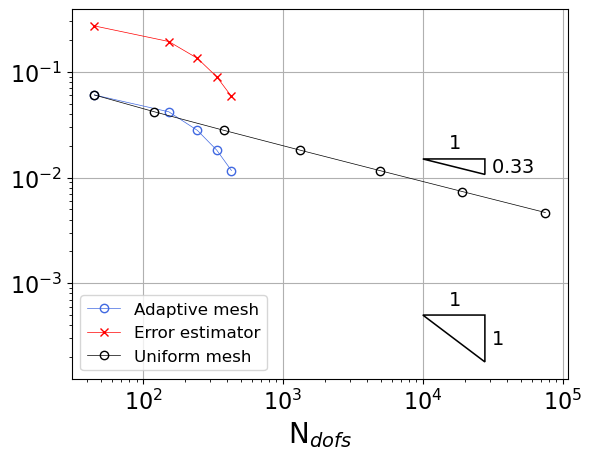

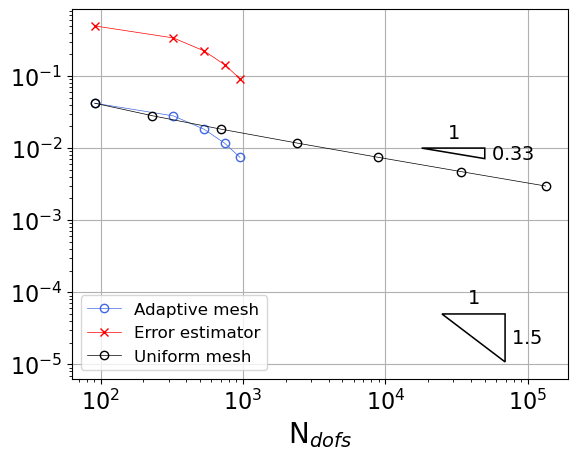

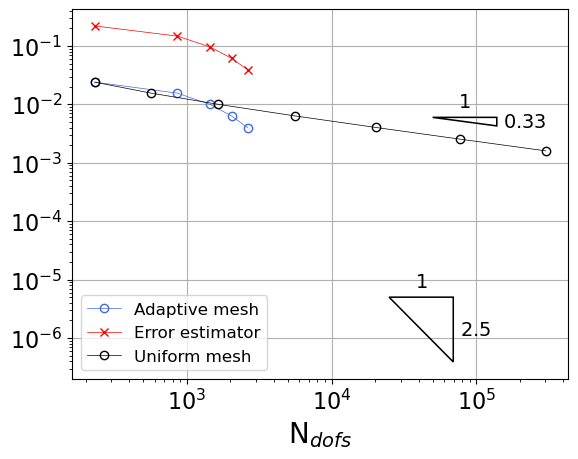

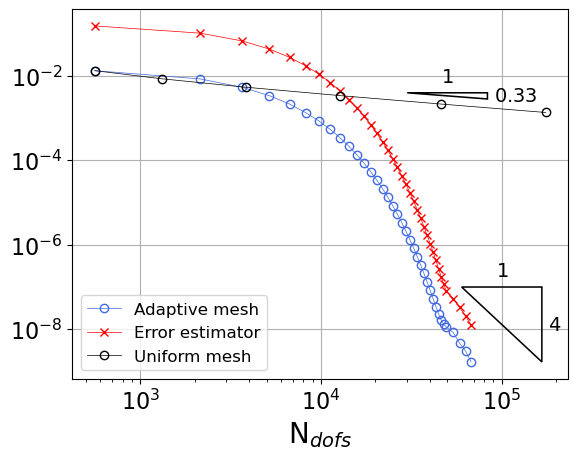

In [29]:
numdofs=R_u[:,0]
numdofs_a = R[:,0]
Eerr = R_u[:,2]
Eerr_a = R[:,2]
pos=((1e4,5*1e-4),(2.5*1e4,5*1e-5),(2.5*1e4,5*1e-6),(6*1e4,1e-7))
pos_u=((1e4,0.15*1e-1),(1.8*1e4,1e-2),(5*1e4,6*1e-3),(3*1e4,4*1e-3))
for i, deg in enumerate((2,3,5,8)):
    numdofs=R_u[:,i*5+0]
    numdofs_a = R[:,i*5+0]
    Eerr = R_u[:,i*5+2]
    Eerr_a = R[:,i*5+2]
    Eta = R[:,i*5+3]

    numdofs=numdofs[numdofs!=0]
    numdofs_a=numdofs_a[numdofs_a != 0]
    Eerr_a = Eerr_a[Eerr_a!=0]
    Eerr = Eerr[Eerr!=0]
    Eta = Eta[Eta!=0]
    
    fig, ax = plt.subplots()
    plt.loglog(numdofs_a, Eerr_a, 'o-',color='royalblue',linewidth=0.5, markerfacecolor='none')
    plt.loglog(numdofs_a, Eta, 'x-',color='red',linewidth=0.5, markerfacecolor='none')
    plt.loglog(numdofs, Eerr, 'o-',color='black',linewidth=0.5, markerfacecolor='none')
    plt.grid('True');
    ax.tick_params(axis='both', labelsize=16)
    plt.legend(['Adaptive mesh','Error estimator','Uniform mesh'],loc='lower left',prop={'size': 12})
    plt.xlabel("N$_{dofs}$",size=20)
    draw_loglog_slope(fig,ax,pos[i],2,slope=int(deg/2) if deg%2==0 else deg/2,inverted=False, color='black', polygon_kwargs=None, label=True, labelcolor=None, label_kwargs={'fontsize':14}, zorder=None)
    draw_loglog_slope(fig,ax,pos_u[i],2,0.33,inverted=False, color='black', polygon_kwargs=None, label=True, labelcolor=None, label_kwargs={'fontsize':14}, zorder=None)

    plt.savefig('Lp'+str(deg)+'n'+str(deg+1)+'H1_cnv.pdf', bbox_inches='tight')
    plt.show()
    